# Experiment Control

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.ndimage import gaussian_filter
import matplotlib 
matplotlib.rc('font', family='serif')
matplotlib.rc('font', serif='STIXGeneral')
from cmcrameri import cm  #cmap=cm.lipari 

from optical_setup import OpticalSetup
from CAM.vimbPy.controller import VimbaXController
from time import sleep
opt_setup = OpticalSetup()


## DMD

Initialise

In [15]:
opt_setup._dmd_on()

matrix_height = int(opt_setup.dmd.h)
matrix_width = int(opt_setup.dmd.w)

2026-06-02 13:39:23,615 - ALP41 - SN16017 - INFO - Device connected. SN: 16017, ID: 280
2026-06-02 13:39:23,615 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 1
2026-06-02 13:39:23,615 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 2
2026-06-02 13:39:23,623 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 3
2026-06-02 13:39:23,624 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 4
2026-06-02 13:39:23,625 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 5


### Objects

Two Filled Dots

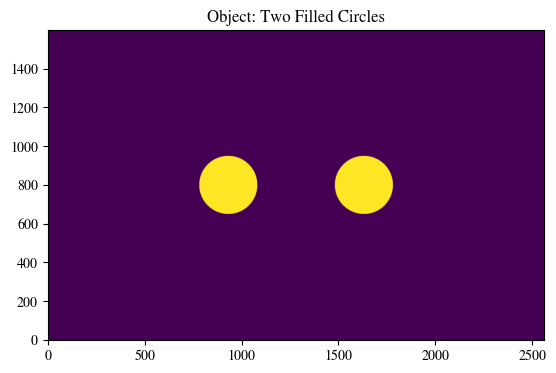

In [3]:
# Object matrix
two_dots = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2
seperation = 700

# Circle settings
radius = 150

# Circle centres
x1 = centre_x - seperation // 2
x2 = centre_x + seperation // 2
y1 = y2 = centre_y

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= radius**2

# Set circle pixels
two_dots[mask1] = 255
two_dots[mask2] = 255

# Convert to uint8
two_dots = two_dots.astype(np.uint8)

# Display
plt.imshow(two_dots, origin='lower')
plt.title("Object: Two Filled Circles")
plt.show()

Three Filled Dots

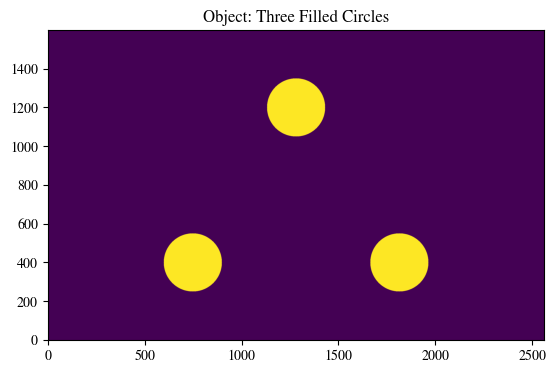

In [4]:

# Object matrix
three_dots = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2
separation = 800

# Circle settings
radius = 150

# Circle centres
x1 = centre_x - separation//1.5
x2 = centre_x + separation//1.5
x3 = centre_x
y1 = y2 = centre_y - separation//2
y3 = centre_y + separation//2

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= radius**2
mask3 = (X - x3)**2 + (Y - y3)**2 <= radius**2

# Set circle pixels
three_dots[mask1] = 255
three_dots[mask2] = 255
three_dots[mask3] = 255

# Convert to uint8
three_dots = three_dots.astype(np.uint8)

# Display
plt.imshow(three_dots, origin='lower')
plt.title("Object: Three Filled Circles")
plt.show()

Four Filled Dots

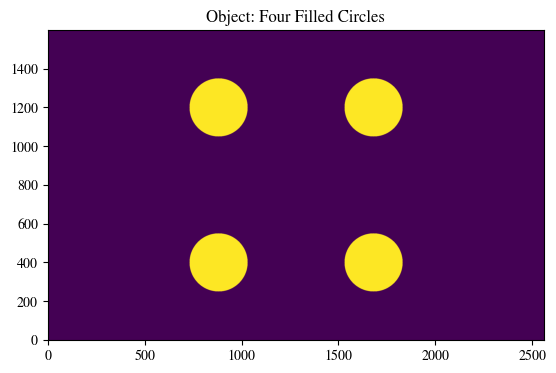

In [5]:
# Object matrix
four_dots = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2
separation = 800

# Circle settings
radius = 150

# Circle centres
x1 = centre_x - separation
x2 = centre_x + separation
x3 = centre_x
x4 = centre_x
y1 = y2 = y3 = centre_y

x1 = x2 = centre_x + separation//2
y2 = y3 = centre_y - separation//2
x3 = x4 = centre_x - separation//2
y4 = y1 = centre_y + separation//2

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= radius**2
mask3 = (X - x3)**2 + (Y - y3)**2 <= radius**2
mask4 = (X - x4)**2 + (Y - y4)**2 <= radius**2

# Set circle pixels
four_dots[mask1] = 255
four_dots[mask2] = 255
four_dots[mask3] = 255
four_dots[mask4] = 255

# Convert to uint8
four_dots = four_dots.astype(np.uint8)

# Display
plt.imshow(four_dots, origin='lower')
plt.title("Object: Four Filled Circles")
plt.show()

Ring

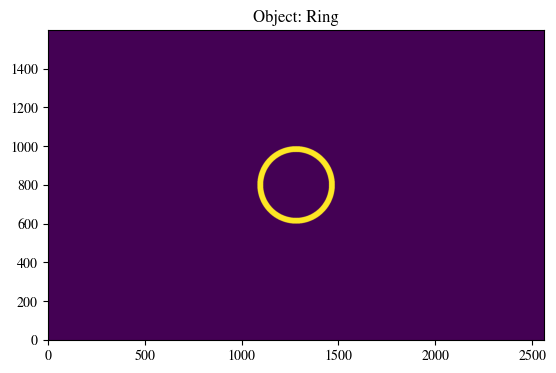

In [6]:
# Object matrix
ring = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2

# Circle settings
outer_radius = 200
inner_radius = 170

# Circle centres
x1 = x2 = centre_x
y1 = y2 = centre_y

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= outer_radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= inner_radius**2

# Set circle pixels
ring[mask1] = 255
ring[mask2] = 0

# Convert to uint8
ring = ring.astype(np.uint8)

# Display
plt.imshow(ring, origin='lower')
plt.title("Object: Ring")
plt.show()

DMD On

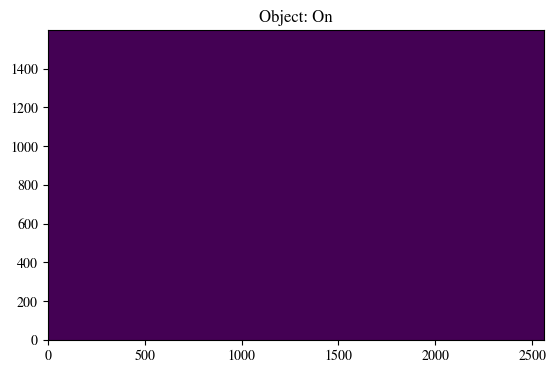

In [7]:
# Object matrix
On = np.ones((matrix_height, matrix_width))*255
#On[:1000, :1000] = 255




# Convert to uint8
On = On.astype(np.uint8)

# Display
plt.imshow(On, origin='lower')
plt.title("Object: On")
plt.show()

### Send To DMD

In [25]:
patterns_dict = {"two dots": two_dots, "three dots": three_dots, "four dots": four_dots, "ring": ring, "on": On}
Pattern = patterns_dict["on"]  # Change the key to select different patterns

Pattern=Pattern[np.newaxis, np.newaxis, :, :]  # Add batch and channel dimensions
opt_setup._dmd_display(pattern=Pattern , continuous=False)

## Camera 

Take a picture

2026-06-02 15:38:29,600 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Packet size adjusted successfully.
2026-06-02 15:38:29,604 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record started.


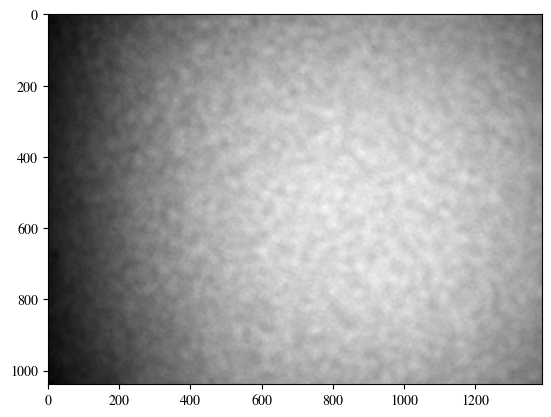

2026-06-02 15:38:30,475 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record stopped.


In [29]:
opt_setup._cams_off()
opt_setup._cams_on()
opt_setup.trigger_camera()

frame = opt_setup.q_single.get()

img = frame[1]

plt.imshow(img.squeeze(), cmap='gray')
plt.show()

custom_name = "C:\\Users\\lj500\\OneDrive - University of Exeter\\Desktop\\Imaging & tracking objects behind a scattering medium\\data\\blank_speckle\\speckle_32286_micro_s_aperture.png"

plt.imsave(custom_name, img.squeeze(), cmap="gray")

opt_setup._cams_off()

In [30]:
opt_setup._dmd_off()

2026-06-02 15:39:17,058 - ALP41 - SN16017 - INFO - Memory freed successfully. SeqID: 5
2026-06-02 15:39:17,058 - ALP41 - SN16017 - INFO - Memory freed successfully. SeqID: 1
2026-06-02 15:39:17,065 - ALP41 - SN16017 - INFO - Memory freed successfully. SeqID: 2
2026-06-02 15:39:17,065 - ALP41 - SN16017 - INFO - Memory freed successfully. SeqID: 3
2026-06-02 15:39:17,065 - ALP41 - SN16017 - INFO - Memory freed successfully. SeqID: 4
2026-06-02 15:39:17,087 - ALP41 - SN16017 - INFO - Device disconnected. SN: 16017
